# U‑Net–Based Biomedical Cell Segmentation






This notebook implements a complete deep‑learning workflow for biomedical cell segmentation using a U‑Net architecture. It covers data preparation, preprocessing, augmentation, model training, and evaluation, providing a clear and reproducible pipeline for semantic segmentation in microscopy imaging.

# Dataset and Data Aquisition

The experiments in this notebook use the BCCD dataset, published on Kaggle by Jeet B. Lahiri. The dataset contains microscopy images of various cells together with corresponding pixel‑level annotations for semantic segmentation. The images and masks were downloaded directly from the Kaggle dataset page and are not included in this repository.

The dataset is distributed under the MIT Licence. Users should refer to the original Kaggle page for full licence terms and authorship information.

In [ ]:
# Mount Google Drive to access the dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Extract the dataset ZIP file directly from Google Drive into the Colab environment.
import zipfile

zip_path = "/content/drive/MyDrive/BCCD_Dataset_With_Mask.zip"
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall("bccd")

print("Dataset extracted to: bccd/")


Dataset extracted to: bccd/


# Data Preprocessing

This section prepares the dataset for training by standardising image dimensions, normalising pixel intensities, and constructing reproducible training, validation, and test splits. All images and masks are resized to 256×256 to provide a consistent input resolution for the U‑Net architecture. After preprocessing, a visual inspection is performed to verify that each image is correctly paired with its corresponding mask.

In [ ]:
# Core libraries for file handling, image processing, and numerial operations.
import os
import cv2
import numpy as np

# Plotting and visualisation
import matplotlib.pyplot as plt

# Data Augmentation
import albumentations as A

# Deep Learning framework
import tensorflow as tf
from tensorflow.keras import layers, models, backend as K

# Dataset splitting and evaluation metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import jaccard_score, precision_score, recall_score


In [ ]:
# Paths to the extracted dataset folders
TRAIN_IMG_DIR = "/content/bccd/BCCD Dataset with mask/train/original"
TRAIN_MASK_DIR = "/content/bccd/BCCD Dataset with mask/train/mask"

TEST_IMG_DIR = "/content/bccd/BCCD Dataset with mask/test/original"
TEST_MASK_DIR = "/content/bccd/BCCD Dataset with mask/test/mask"

# Target image size for U-Net and classical segmentation comparison.
IMG_SIZE = 256

**Resize and Reload Functions :**

In [ ]:
# Load an image from disk, convert to RGB, resize to 256x256, and normalise to [0,1].
def load_image(path):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    return img.astype("float32") / 255.0

# Load a segmentation mask, convert to grayscale, resize, and binarise.
# Binarisation ensures the mask is 0 (background) or 1 (cell).
def load_mask(path):
    mask = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))
    mask = (mask > 0).astype("float32") # convert to binary mask
    return np.expand_dims(mask, axis=-1) # add channel dimension


**Collect all Images and Masks :**

In [ ]:
# Collect file paths from train and test folders
train_images = sorted([os.path.join(TRAIN_IMG_DIR, f) for f in os.listdir(TRAIN_IMG_DIR)])
train_masks  = sorted([os.path.join(TRAIN_MASK_DIR, f) for f in os.listdir(TRAIN_MASK_DIR)])

test_images = sorted([os.path.join(TEST_IMG_DIR, f) for f in os.listdir(TEST_IMG_DIR)])
test_masks  = sorted([os.path.join(TEST_MASK_DIR, f) for f in os.listdir(TEST_MASK_DIR)])

# Combine them into one dataset
all_images = train_images + test_images
all_masks  = train_masks + test_masks

# Load into arrays
X = np.array([load_image(f) for f in all_images])
y = np.array([load_mask(f) for f in all_masks])

print("Loaded images:", X.shape)
print("Loaded masks:", y.shape)


Loaded images: (1328, 256, 256, 3)
Loaded masks: (1328, 256, 256, 1)


**Train / Validation / Test Split :**

In [ ]:
# First split: train vs temp (val & test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.20, random_state=42
)


# Second split: validation vs test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print("Train set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)


Train set: (1062, 256, 256, 3)
Validation set: (133, 256, 256, 3)
Test set: (133, 256, 256, 3)


**Visually Check Image and Mask pairs are consistent :**

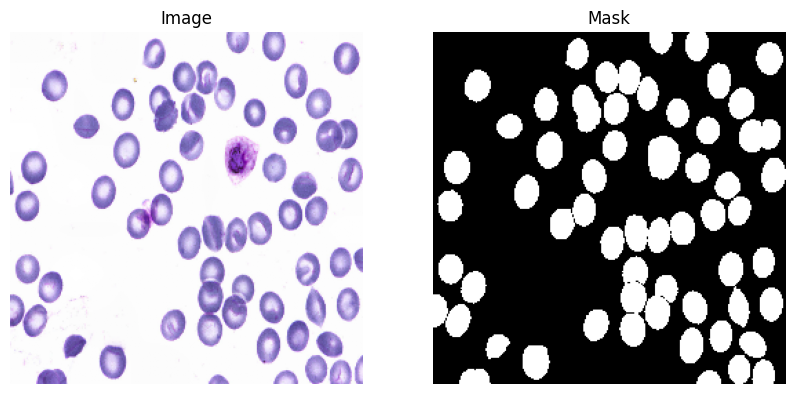

In [ ]:
i = 0  # any index from 0 to len(X)-1

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Image")
plt.imshow(X[i])
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Mask")
plt.imshow(y[i].squeeze(), cmap="gray")
plt.axis("off")

plt.show()


# Data Augmentation (Training‑Only) :

Augmentation introduces controlled variability into the training data to improve the model’s ability to generalise to unseen samples. The transformations applied include rotations, flips, affine adjustments, and intensity variations. Augmentation is applied exclusively to the training set; the validation and test sets remain unchanged to ensure unbiased evaluation.

In [ ]:
# Data augmentation using Albumentations.
# These transformations simulate realistic variations in microscopy images
# while preserving the biological structure of the cells.

augment = A.Compose([
    A.HorizontalFlip(p=0.5),          # flip images horizontally
    A.VerticalFlip(p=0.5),            # flip images vertically
    A.RandomRotate90(p=0.5),          # rotate by 90-degree increments

    # Replacement for ShiftScaleRotate
    A.Affine(
        scale=(0.9, 1.1),             # zoom in/out +/-10%
        translate_percent=(0.05, 0.05),  # shift up to 5%
        rotate=(-15, 15),             # rotate +/- 15 degrees
        p=0.5
    ),                                # small shifts, zooms, and rotations

    A.RandomBrightnessContrast(
        brightness_limit=0.2,
        contrast_limit=0.2,
        p=0.3
    ),                                      # simulate lighting variation
])


In [ ]:
# Apply augmentation to an image-mask pair training batches
# Albumentations ensures that the same transformation is applied to both.

def augment_pair(image, mask):
    augmented = augment(image=image, mask=mask)
    return augmented["image"], augmented["mask"]


**Check the Augumentation are biologically reasonable :**

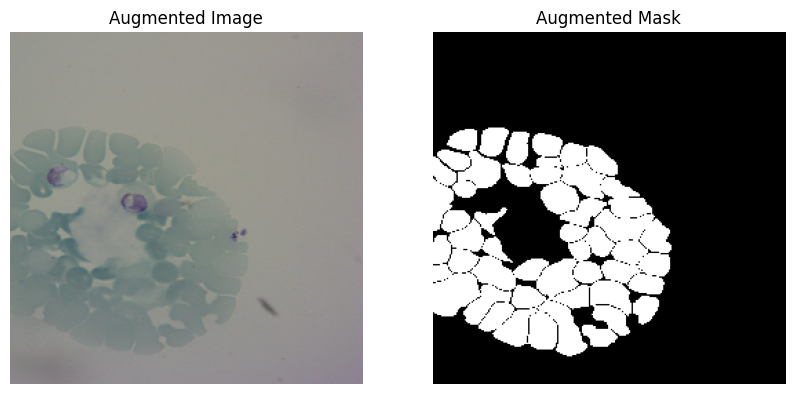

In [ ]:
# Visualise a few augmented samples to verify correctness.

idx = 0  # choose any index from the training set
sample_img = X_train[idx]
sample_mask = y_train[idx]

aug_img, aug_mask = augment_pair(sample_img, sample_mask)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Augmented Image")
plt.imshow(aug_img)
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Augmented Mask")
plt.imshow(aug_mask.squeeze(), cmap="gray")
plt.axis("off")

plt.show()


# U-Net Model Architecture

U‑Net is a convolutional encoder–decoder architecture with skip connections that transfer spatial information from the contracting path to the expanding path. This design enables precise localisation while maintaining contextual understanding, making it well suited for pixel‑wise segmentation tasks in biomedical imaging. The model used in this notebook follows the standard U‑Net configuration, consisting of successive downsampling and upsampling blocks with feature concatenation at each resolution level.

In [ ]:
# U-Net architecture for biomedical image segmentation.
# This implementation follows the standard encoder-decoder structure with skip connections.

def conv_block(x, filters):
    # Two convolutional layers with ReLU activation and same padding.
    x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
    x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
    return x

def encoder_block(x, filters):
    # Convolution block followed by max pooling for downsampling.
    f = conv_block(x, filters)
    p = layers.MaxPooling2D((2, 2))(f)
    return f, p

def decoder_block(x, skip, filters):
    # Upsampling followed by concatenation with skip connection.
    x = layers.UpSampling2D((2, 2))(x)
    x = layers.Concatenate()([x, skip])
    x = conv_block(x, filters)
    return x

def build_unet(input_shape=(256, 256, 3)):
    inputs = layers.Input(input_shape)

    # Encoder
    s1, p1 = encoder_block(inputs, 64)
    s2, p2 = encoder_block(p1, 128)
    s3, p3 = encoder_block(p2, 256)
    s4, p4 = encoder_block(p3, 512)

    # Bottleneck
    b = conv_block(p4, 1024)

    # Decoder
    d1 = decoder_block(b, s4, 512)
    d2 = decoder_block(d1, s3, 256)
    d3 = decoder_block(d2, s2, 128)
    d4 = decoder_block(d3, s1, 64)

    # Output layer: 1 channel mask with sigmoid activation.
    outputs = layers.Conv2D(1, 1, padding="same", activation="sigmoid")(d4)

    model = models.Model(inputs, outputs)
    return model

unet = build_unet()
unet.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │    147,584 │ conv2d_2[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │    590,080 │ conv2d_4[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │  1,180,160 │ max_pooling2d_2[… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │  2,359,808 │ conv2d_6[0][0]    │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 16, 16,    │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 16, 16,    │  4,719,616 │ max_pooling2d_3[… │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 16, 16,    │  9,438,208 │ conv2d_8[0][0]    │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 32, 32,    │          0 │ conv2d_9[0][0]    │
│ (UpSampling2D)      │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 32, 32,    │          0 │ up_sampling2d[0]

 Total params: 31,378,945 (119.70 MB)

 Trainable params: 31,378,945 (119.70 MB)

 Non-trainable params: 0 (0.00 B)

# Training Procedure

This section defines the loss function, optimisation strategy, and training procedure used for the U‑Net model. The network is trained using a combination of Binary Cross‑Entropy and Dice loss, which balances pixel‑wise accuracy with overlap‑based optimisation. The model is optimised with Adam and trained for 30 epochs using the predefined training, validation, and test splits.

**Dice Coefficient and Dice Loss Functions :**

In [ ]:
# Dice coefficient measures overlap between predicted and true masks.
# Dice loss = 1 - Dice coefficient, encouraging higher overlap.

def dice_coefficient(y_true, y_pred, smooth=1e-6):
    # Flatten tensors to compute overlap.
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)

    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f) + K.sum(y_pred_f)

    dice = (2. * intersection + smooth) / (union + smooth)
    return dice

def dice_loss(y_true, y_pred):
    return 1 - dice_coefficient(y_true, y_pred)


**Combined BCE and Dice Loss :**

In [ ]:
# Combined loss: Binary Cross-Entropy + Dice Loss.
# This aims to balance pixel-level accuracy with region-level overlap.

bce = tf.keras.losses.BinaryCrossentropy()

def bce_dice_loss(y_true, y_pred):
    return bce(y_true, y_pred) + dice_loss(y_true, y_pred)


**Compile the U-Net Model :**

In [ ]:
# Compile the U-Net with Adam optimiser and the combined loss.
# Dice coefficient is added as a metric for monitoring segmentation quality.

unet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=bce_dice_loss,
    metrics=[dice_coefficient]
)

print("U-Net compiled and ready for training.")


U-Net compiled and ready for training.


**Training Loop :**

In [ ]:
# Train the U-Net model using the preprocessed dataset.
# Validation data is used for early stopping and monitoring overfitting.

history = unet.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=8,
    verbose=1
)

Epoch 1/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 225s 1s/step - dice_coefficient: 0.6876 - loss: 0.6199 - val_dice_coefficient: 0.8727 - val_loss: 0.2605
Epoch 2/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 73s 552ms/step - dice_coefficient: 0.9033 - loss: 0.2163 - val_dice_coefficient: 0.9133 - val_loss: 0.1809
Epoch 3/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 75s 561ms/step - dice_coefficient: 0.9238 - loss: 0.1729 - val_dice_coefficient: 0.9318 - val_loss: 0.1711
Epoch 4/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 74s 559ms/step - dice_coefficient: 0.9270 - loss: 0.1656 - val_dice_coefficient: 0.9415 - val_loss: 0.1372
Epoch 5/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 74s 560ms/step - dice_coefficient: 0.9393 - loss: 0.1381 - val_dice_coefficient: 0.9472 - val_loss: 0.1223
Epoch 6/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 75s 562ms/step - dice_coefficient: 0.9435 - loss: 0.1299 - val_dice_coefficient: 0.9296 - val_loss: 0.1566
Epoch 7/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 74s 554ms/step - dice_coefficient: 0.9427 - loss: 0.1301 - val_dice_coefficient:

# Training Curve Visualisation


This section presents the training and validation curves for the loss and Dice coefficient. These plots provide a qualitative assessment of optimisation behaviour and help verify that the model converges without signs of instability or overfitting.

**Training-Validation Loss Curve :**

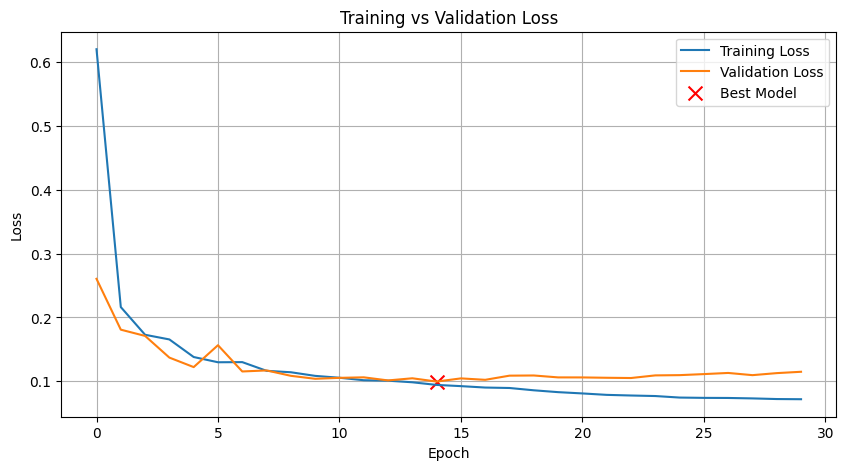

In [21]:
# Plot training and validation loss curves to observe optimisation behaviour.

# Store training and validation history
val_loss = history.history["val_loss"]
train_loss = history.history["loss"]

# Extract the best epoch
best_epoch = np.argmin(val_loss)
best_val = np.min(val_loss)

plt.figure(figsize=(10, 5))
plt.plot(train_loss, label="Training Loss")
plt.plot(val_loss, label="Validation Loss")
plt.scatter(best_epoch, best_val, color="red", marker="x", s=100, label="Best Model")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


**Training-Validation Dice Coefficient Curve :**

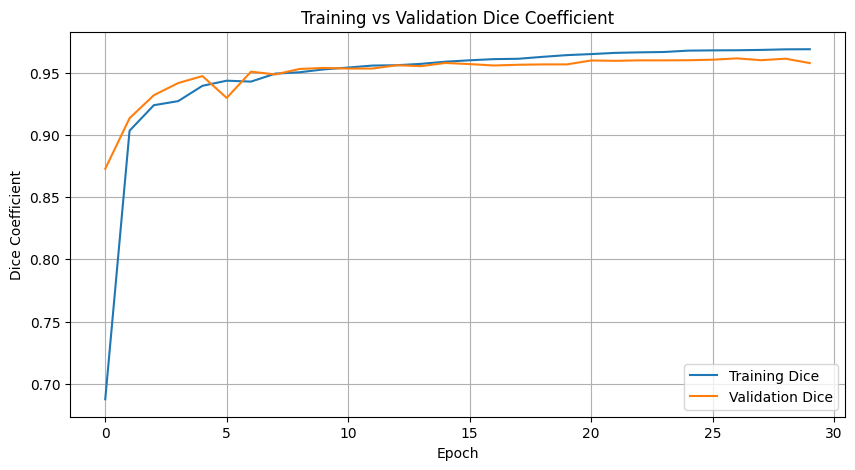

In [22]:
# Plot training and validation Dice coefficient curves.
# Dice is a direct measure of segmentation quality (higher is better).

plt.figure(figsize=(10, 5))
plt.plot(history.history["dice_coefficient"], label="Training Dice")
plt.plot(history.history["val_dice_coefficient"], label="Validation Dice")

plt.title("Training vs Validation Dice Coefficient")
plt.xlabel("Epoch")
plt.ylabel("Dice Coefficient")
plt.legend()
plt.grid(True)
plt.show()


# Model Evaluation and Qualitative Analysis

This section reports the quantitative performance of the trained U‑Net model and provides qualitative examples of its segmentation outputs. Evaluation metrics include loss, Dice coefficient, Intersection over Union (IoU), precision, and recall, calculated on the held‑out test set. Qualitative visualisations compare the input image, ground‑truth mask, and predicted mask to assess segmentation quality and boundary localisation.

**Quantitative Metrics :**

In [23]:
# Evaluate model
test_results = unet.evaluate(X_test, y_test, verbose=1)
print(f"Test Dice Coefficient: {test_results[1]:.4f}")
print(f"Test Loss: {test_results[0]:.4f}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 60s 553ms/step - dice_coefficient: 0.9567 - loss: 0.1138
Test Dice Coefficient: 0.9567
Test Loss: 0.1138


In [24]:
# Calculate test-set segmentation metrics (IoU, precision, recall)

preds = unet.predict(X_test)
preds_bin = (preds > 0.5).astype("float32")

iou = jaccard_score(y_test.flatten(), preds_bin.flatten())
precision = precision_score(y_test.flatten(), preds_bin.flatten())
recall = recall_score(y_test.flatten(), preds_bin.flatten())

print("IoU:", iou)
print("Precision:", precision)
print("Recall:", recall)


5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 920ms/step
IoU: 0.9294861016675359
Precision: 0.9650977416446659
Recall: 0.9618169851229893


**Qualitiative Visualisation :**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step


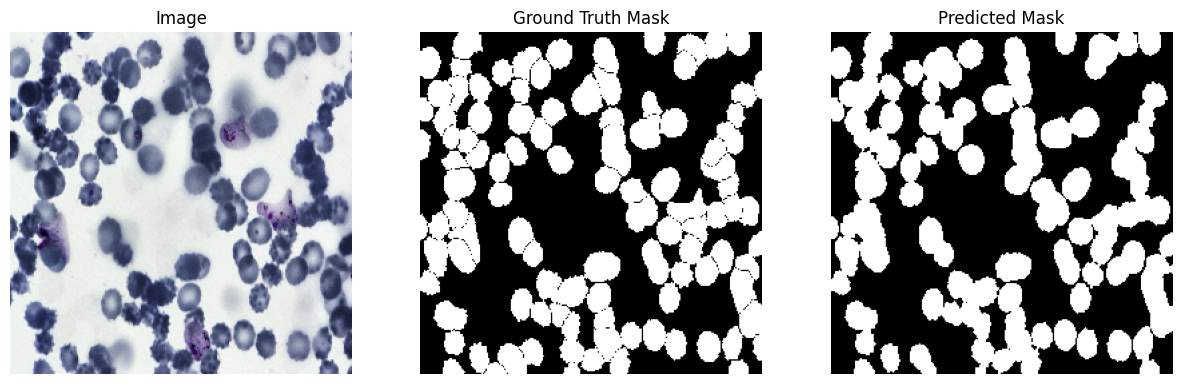

In [32]:
# Pick an index from the test set

i = 27   #change this number to inspect different samples

# Get the image and ground truth mask
img = X_test[i]
true_mask = y_test[i]

# Predict
pred_mask = unet.predict(img[np.newaxis, ...])[0]
pred_mask = (pred_mask > 0.5).astype("float32")  # threshold

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.title("Image")
plt.imshow(img)
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Ground Truth Mask")
plt.imshow(true_mask.squeeze(), cmap="gray")
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Predicted Mask")
plt.imshow(pred_mask.squeeze(), cmap="gray")
plt.axis("off")

plt.show()


# Limitations and Future Work

This section summarises the main limitations of the current approach and outlines potential directions for extending the work. These points contextualise the results and indicate how the model and methodology could be developed further in more realistic or challenging settings.

**Limitations :**

* **Dataset cleanliness :** The dataset used in this project contains high‑quality images and masks, which simplifies the segmentation task. Real‑world biomedical data often includes noise, staining variability, overlapping cells, and imperfect annotations, which were not fully represented here.

* **Single modality :** The model was trained on one imaging modality and one dataset. Performance may not generalise to other microscopy types (e.g., fluorescence, phase‑contrast) without retraining or domain adaptation.

* **No instance separation :** The model predicts binary masks, not instance‑level segmentation. In dense regions, touching nuclei are not separated into individual objects.

* **No annotation uncertainty :** Ground‑truth masks were treated as perfect, but real annotations often contain inter‑annotator variability that affects model performance.

**Future Work :**

* **Training on more diverse datasets :** Incorporating additional microscopy datasets would test generalisation and robustness.

* **Instance segmentation :** Extending the model to Mask R‑CNN, StarDist, or Cellpose would enable better separation of touching cells.

* **Self‑generated masks :** Creating one's own masks would introduce annotation noise and force the model to handle more realistic variability. This would add value, not just on the grounds of IoU improvement, but also as a test of robustness.

* **Uncertainty estimation :** Adding Monte Carlo dropout or test‑time augmentation could quantify prediction confidence.

# Conclusion

This project implemented a complete U‑Net–based workflow for biomedical cell segmentation on the BCCD dataset, covering data preprocessing, augmentation, model training, evaluation, and qualitative analysis. The results demonstrate a stable and reproducible segmentation pipeline suitable for small‑scale microscopy data. While the dataset’s cleanliness limits the complexity of the task, the workflow provides a solid foundation for extending the model to more diverse datasets, instance‑level segmentation, and uncertainty‑aware approaches.